In [ ]:
# import os, sys
# sys.path.insert(0, os.path.normpath(os.path.join(os.getcwd(), '..')))

In [119]:
!export PREFECT__LOGGING__LEVEL="WARNING"

In [48]:
import os
import pandas as pd
import numpy as np
from datetime import datetime, timezone, timedelta
pd.options.plotting.backend = "plotly"

import optuna

optuna.logging.set_verbosity(optuna.logging.CRITICAL)
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

from qtrader.rlflow.persistence import SQLitePersistenceProvider
from qtrader.agents.dq import DQAgent
from qtrader.environments.backtesting import run_backtest_strict

In [49]:
model_name = 'Model_Live'
path = f'/Users/anzekravanja/Projects/smart-trader/opt/{model_name}'
symbol = 'BTCUSD'
symbol_path = os.path.join("./data", f'{symbol}.csv')
date_start = datetime(2020, 3, 1).replace(tzinfo=timezone.utc)
date_end = datetime(2020, 6, 1).replace(tzinfo=timezone.utc) #datetime(2022, 12, 31)

In [50]:
pprovider = SQLitePersistenceProvider(root=path, dbname='eval.sqlite')

In [51]:
agent = DQAgent(
    name=model_name, pprovider=pprovider,
    invest_pct=0.05, invest_max=0.12,  # how much to invest in an order
    exp_memory_size=365*100,
    no_learn = True, no_full_state=False
)

In [ ]:
score = run_backtest_strict(
    data_symbols=[(symbol, symbol_path)], 
    agent=agent, pprovider=pprovider,
    cash_starting=1000,
    dt_from=date_start,
    dt_to=date_end,
    crypto=True
)

In [62]:
df_sy = pd.read_csv(symbol_path, parse_dates=True, index_col='datetime')
df_sy['ts'] = df_sy.index
df_sy['ts'] = df_sy['ts'].apply(lambda dt: datetime.fromisoformat(dt) if isinstance(dt, str) else dt)
df_sy = df_sy.loc[date_start:date_end]

In [86]:
score = pprovider.load_dict('Score')
trades = pprovider.load_dict('Trade-Orders')
df_t = pd.DataFrame([o for t in trades[symbol] for o in t])
df_t['ts'] = df_t['datetime'].apply(lambda dt: datetime.fromisoformat(dt).date())

In [18]:
states = []
for skey in list(pprovider.list(agent.state_prefix))[::-1]:
    states.append(pprovider.load_dict(skey))

In [68]:
df_pnl = pd.DataFrame([(datetime.fromisoformat(s['state_global']['account']['current_datetime']), s['state_global']['account']['value']) for s in states], columns=['datetime', 'value'])

In [97]:
score

{'profit': 41.96602351164367,
 'cash_start': 1000,
 'cash_end': 1041.966023511644,
 'eval': {'sqn_trades': None,
  'sqn_orders': None,
  'num_trades': 3,
  'num_orders': 20}}

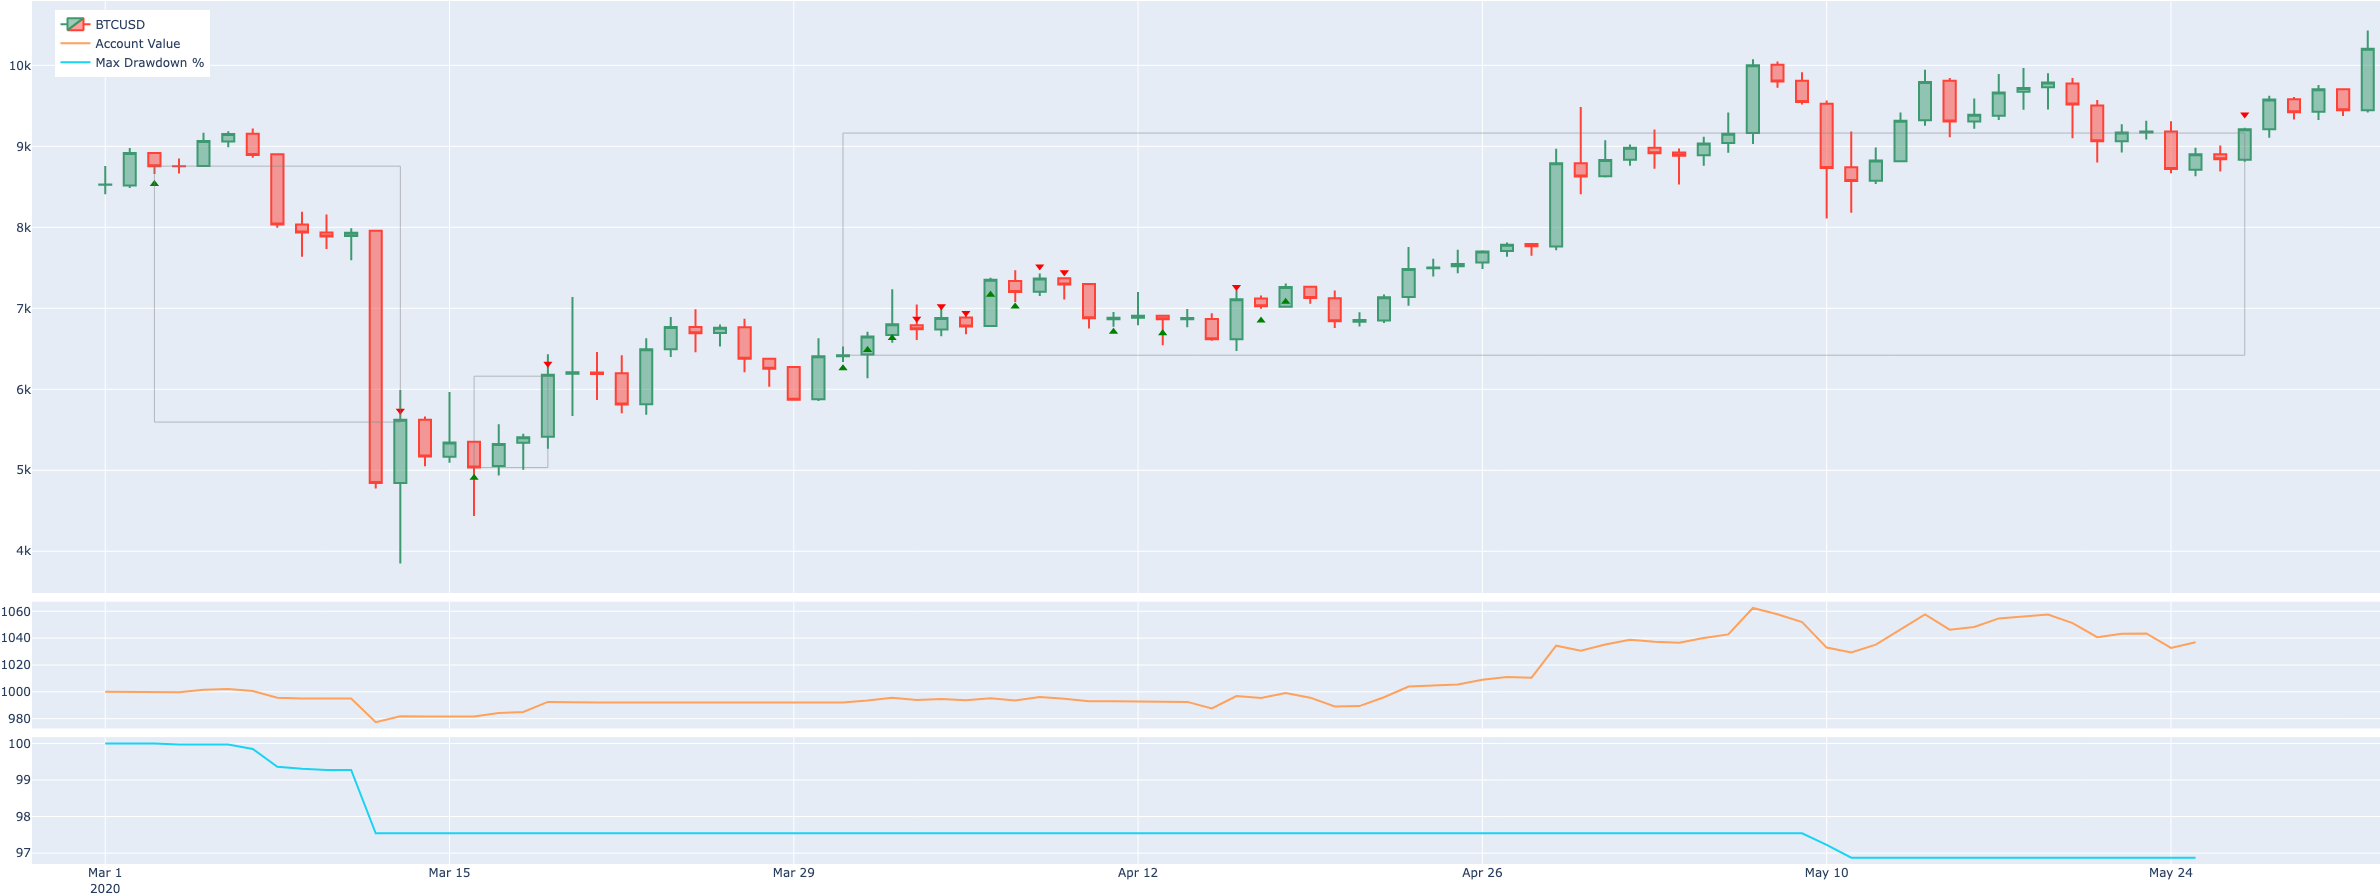

In [139]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=3, cols=1,
    shared_xaxes=True,
    row_heights=[0.7, 0.15, 0.15],
    vertical_spacing=0.01
    # specs=[[{"secondary_y": True}]]
)

# include candlestick with rangeselector
fig.add_trace(go.Candlestick(
    x=df_sy['ts'],
    open=df_sy['open'],
    high=df_sy['high'],
    low=df_sy['low'],
    close=df_sy['close'],
    name=symbol
),
    row=1, col=1
)

for t in trades[symbol]:
    orders = [o for o in t]
    df_tt = pd.DataFrame(orders)
    df_tt['ts'] = df_tt['datetime'].apply(lambda dt: datetime.fromisoformat(dt).date())
    
    y = np.zeros(len(df_tt))
    y[df_tt.instruction.values == "BUY"] = df_tt[df_tt.instruction == "BUY"].price.values * 0.975
    y[df_tt.instruction.values == "SELL"] = df_tt[df_tt.instruction == "SELL"].price.values * 1.025
    fig.add_trace(go.Scatter(
        x=df_tt['ts'],
        y=y,
        mode="markers+text",
        name="Trade",
        # text=df_t.apply(lambda r: f"{r.instruction} / ${round(r['size'] * r['price'], 2)}", axis=1),
        marker_symbol=['triangle-up' if ins == "BUY" else 'triangle-down' for ins in df_tt.instruction.values],
        marker_color=['Green' if ins == "BUY" else 'Red' for ins in df_tt.instruction.values],
        marker_size=8,
        textposition=["bottom center" if ins == "BUY" else "top center" for ins in df_tt.instruction.values],
        showlegend=False
    ),
        row=1, col=1
    )
    
    fig.add_shape(type="rect",
        x0=df_tt.iloc[0].ts, y0=df_tt.iloc[0].price, 
        x1=df_tt.iloc[-1].ts, y1=df_tt.iloc[-1].price,
        line=dict(
            color="Gray",
            width=1,
        ),
                  opacity=0.5
        #fillcolor="LightSkyBlue",
    )

fig.add_trace(go.Scatter(
    x=df_pnl['datetime'],
    y=df_pnl['value'],
    opacity=1,
    mode='lines',
    name='Account Value'
),
    row=2, col=1
)

pnl_cmax = df_pnl.value.cummax()
max_dd = (df_pnl.value / pnl_cmax).cummin()
fig.add_trace(go.Scatter(
    x=df_pnl['datetime'],
    y=max_dd * 100,
    opacity=1,
    mode='lines',
    name='Max Drawdown %'
),
    row=3, col=1
)

fig.update_layout(
    xaxis_rangeslider_visible=False,
    showlegend=True,
    autosize=True,
    margin=dict(
        l=0,
        r=0,
        b=0,
        t=0,
        pad=0
    ),
    height=224 * 4,
)
fig.update_layout(legend=dict(
    yanchor="top",
    y=0.99,
    xanchor="left",
    x=0.01
))
fig.show()

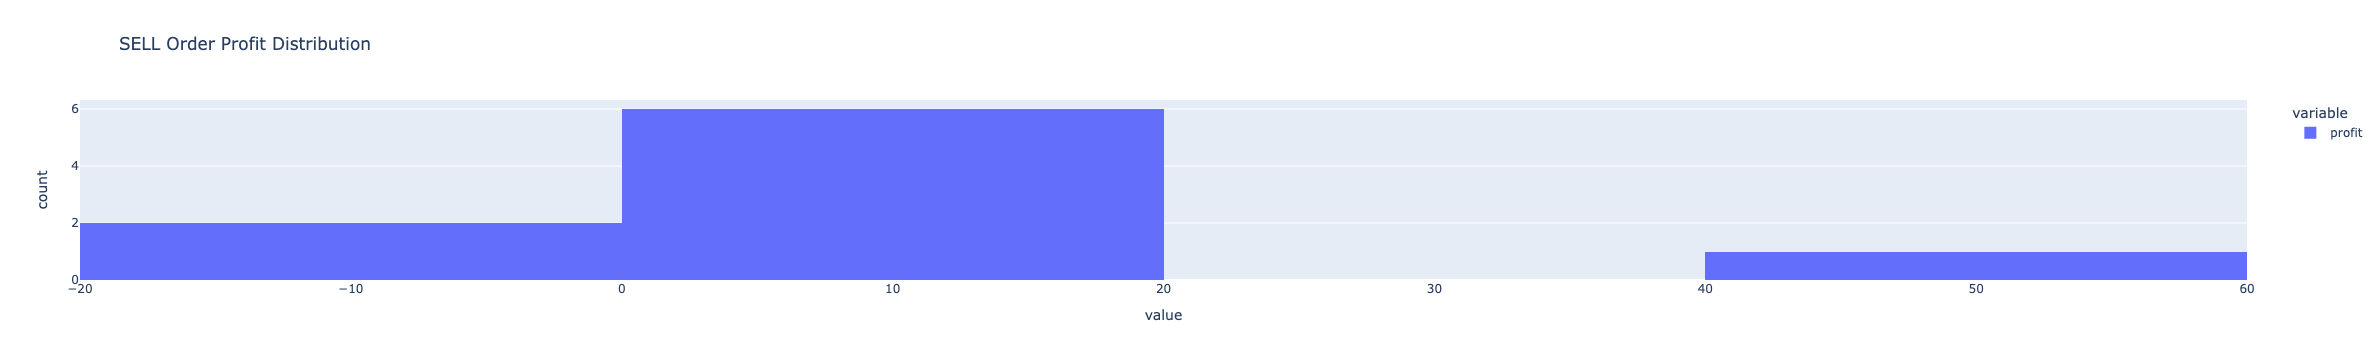

In [105]:
df_t[df_t.instruction == 'SELL']['profit'].hist(title='SELL Order Profit Distribution')

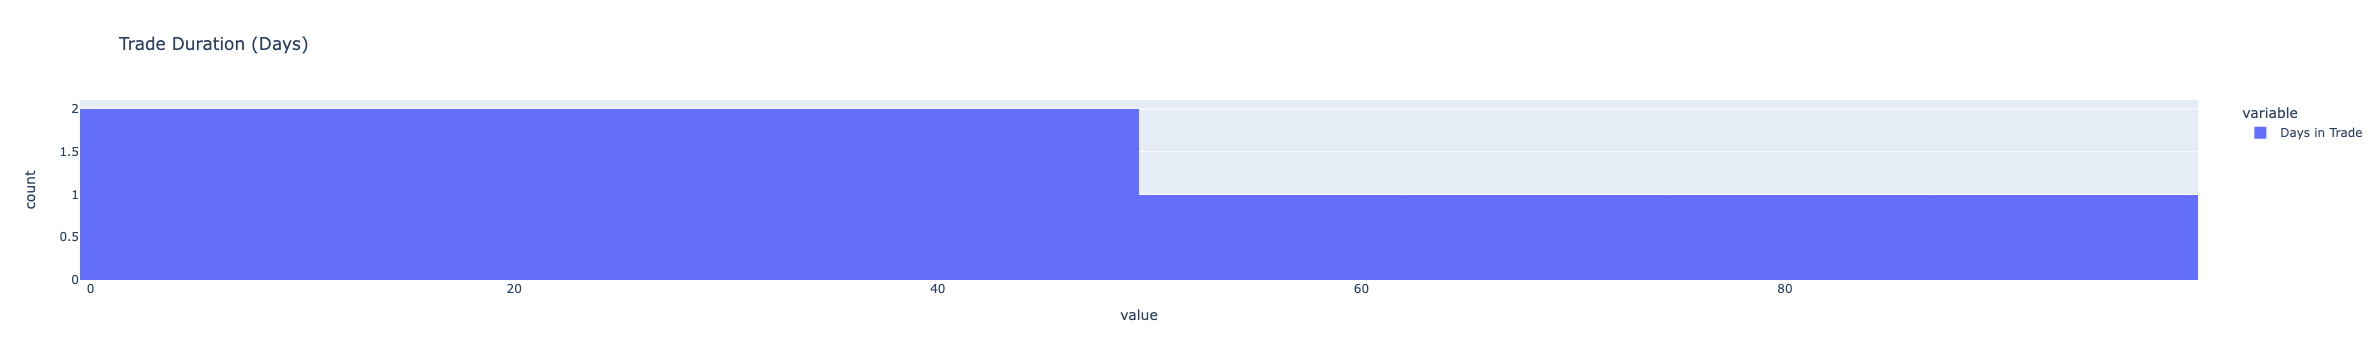

In [118]:
dt_tdays = []
for t in trades[symbol]:
    dt_tdays.append(
        (datetime.fromisoformat(t[-1]['datetime']) - datetime.fromisoformat(t[0]['datetime'])).days
    )
    
dt_tdays = pd.DataFrame(dt_tdays, columns=['Days in Trade'])
dt_tdays.hist(title='Trade Duration (Days)')

In [130]:
pnl_cmax = df_pnl.value.cummax()
max_dd = (df_pnl.value / pnl_cmax).cummin()
pd.Series(max_dd, name='Max Drawdown')

0     1.000000
1     1.000000
2     1.000000
3     0.999738
4     0.999738
        ...   
81    0.968757
82    0.968757
83    0.968757
84    0.968757
85    0.968757
Name: Max Drawdown, Length: 86, dtype: float64